# Regression

In *regression*, the target to be predicted is a **continuous** variable.

This notebook is the first lab in the Machine Learning course. We learn to:

- Load a dataset and explore a feature–target relationship with a scatter plot.
- Fit a `LinearRegression` model, interpret its parameters, and predict new values.
- Estimate model error with the **mean absolute error** (MAE).

In Part B:

- Fit a **multi-variable** linear model on the advertising dataset.
- Use the **pairplot trick** to preview each feature's relationship with the target.
- Interpret the learned **coefficients** in original units.
- Compare every feature combination by training MAE to find the best subset.

## Part A: Linear Regression

We start with a real dataset: years of work experience and salary.

- Feature $x$: `Experience Years`
- Target $y$: `Salary` (continuous — dollars per year)

In [19]:
from pathlib import Path

# https://pandas.pydata.org/docs/
import pandas as pd

# https://docs.python.org/3/library/itertools.html#itertools.combinations
from itertools import combinations

# https://numpy.org/doc/
import numpy as np

# https://seaborn.pydata.org/
import seaborn as sns

# https://matplotlib.org/
import matplotlib.pyplot as plt

# https://scikit-learn.org/stable/modules/linear_model.html#linear-regression
from sklearn.linear_model import LinearRegression

# https://scikit-learn.org/stable/modules/model_evaluation.html#mean-absolute-error
from sklearn.metrics import mean_absolute_error


In [20]:
# Path to the salary dataset, relative to this notebook
data_path = Path("../datasets/Salary Data.csv")

salary_df = pd.read_csv(data_path)
salary_df.head()


,Experience Years,Salary
0,1.1,39343
1,1.2,42774
2,1.3,46205
3,1.5,37731
4,2.0,43525


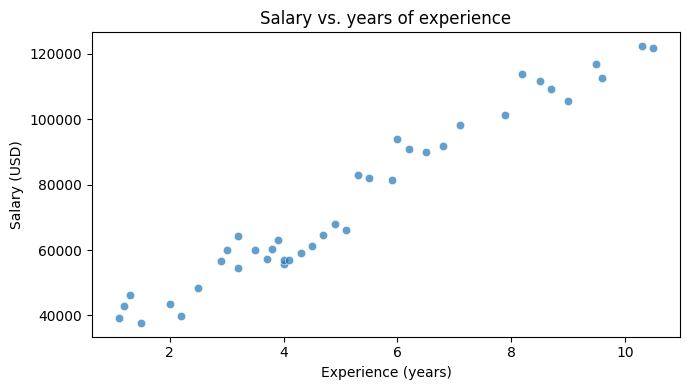

In [21]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.scatterplot(
    data=salary_df,
    x="Experience Years",
    y="Salary",
    ax=ax,
    alpha=0.7,
)
ax.set_title("Salary vs. years of experience")
ax.set_xlabel("Experience (years)")
ax.set_ylabel("Salary (USD)")
plt.tight_layout()
plt.show()


### Split features from target

In supervised learning we separate:

- **Features** $X$ — the columns the model reads.
- **Target** $y$ — the continuous value we want to predict.

In [22]:
feature_name = "Experience Years"
target_name = "Salary"

# Keep feature as a 2-D DataFrame (sklearn expects a matrix, not a 1-D Series)
X = salary_df[[feature_name]]
y = salary_df[target_name]

X.shape, y.shape


((40, 1), (40,))

### Fit a linear model

`LinearRegression` finds the straight line that best fits the training data.

In [23]:
model = LinearRegression()
model.fit(X, y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9523.65]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Experience Years']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.567e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [24]:
slope = model.coef_[0].round(2)
intercept = model.intercept_.round(2)
slope, intercept


(np.float64(9523.65), np.float64(25673.02))

The model learned a line of the form $\hat{y} = \text{slope} \times x + \text{intercept}$. Read the rounded values from the cell above.

### Predict for a single value

For any new experience value, the model returns a predicted salary $\hat{y}$.

In [25]:
years_of_experience = 5

# Pass a 2-D array so the column name matches what the model saw during fit
predicted_salary = model.predict(
    pd.DataFrame({feature_name: [years_of_experience]})
)
predicted_salary


array([73291.26829762])

### Predict over a range and plot the fitted line

In [26]:
experience_range = np.linspace(
    start=X[feature_name].min(),
    stop=X[feature_name].max(),
    num=300,
)

experience_range_df = pd.DataFrame({feature_name: experience_range})
predicted_salaries = model.predict(experience_range_df)


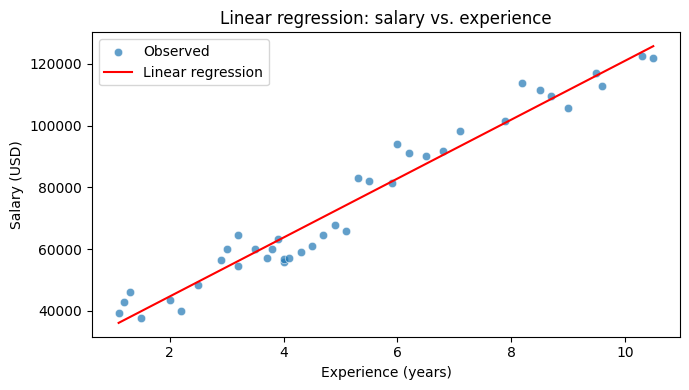

In [27]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.scatterplot(
    data=salary_df,
    x=feature_name,
    y=target_name,
    ax=ax,
    alpha=0.7,
    label="Observed",
)
ax.plot(
    experience_range,
    predicted_salaries,
    color="red",
    label="Linear regression",
)
ax.set_title("Linear regression: salary vs. experience")
ax.set_xlabel("Experience (years)")
ax.set_ylabel("Salary (USD)")
ax.legend()
plt.tight_layout()
plt.show()


### Estimate model error

The **error** for one observation is the vertical distance between the point and the fitted line: $|y_i - \hat{y}_i|$.

The **mean absolute error** (MAE) averages those distances across all training points.

In [28]:
predicted_y = model.predict(X)
residuals = predicted_y - y
residuals.head()


0   -3193.968681
1   -5672.603631
2   -8151.238580
3    2227.491522
4    1195.316775
Name: Salary, dtype: float64

In [29]:
model_error = mean_absolute_error(
    y_true=y,
    y_pred=predicted_y,
)
print(f"Mean absolute error: {model_error:,.0f} USD")


Mean absolute error: 4,516 USD


An MAE of a few thousand dollars means that, on average, our salary predictions are off by that amount given years of experience.

## Part B: Multi-Variable Regression

So far we used one feature. Real models often use several at once.

We switch to the **Advertising** dataset from [*An Introduction to Statistical Learning* (ISLR)](https://www.statlearning.com/):

- Features: `TV`, `Radio`, and `Newspaper` budgets (in $1,000s)
- Target: `Sales` (in 1,000s of units)

With three features, the model becomes:

$$\hat{y} = b + w_1 x_{\text{TV}} + w_2 x_{\text{Radio}} + w_3 x_{\text{Newspaper}}$$

Each weight $w_j$ is that feature's **coefficient** — how much Sales changes when that budget goes up by $1,000, holding the other budgets fixed.

In [30]:
# Path to the advertising dataset, relative to this notebook
adv_path = Path("../datasets/advertising.csv")

adv_df = pd.read_csv(adv_path)
adv_df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


### The pairplot trick

Before fitting, plot each feature against the target with a regression line.

- One call to [`sns.pairplot`](https://seaborn.pydata.org/generated/seaborn.pairplot.html) shows all three relationships side by side.
- The slope of each line previews the sign and strength of that feature's coefficient.

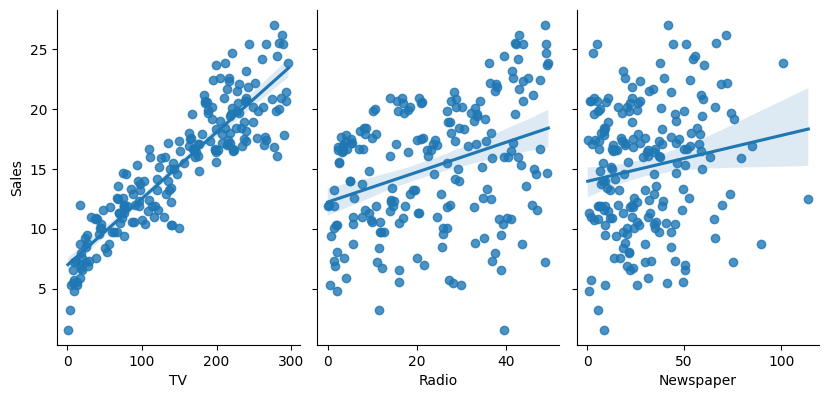

In [31]:
sns.pairplot(
    data=adv_df,
    x_vars=["TV", "Radio", "Newspaper"],
    y_vars="Sales",
    kind="reg",
    height=4,
    aspect=0.7,
)

Reading the plots:

- **TV vs. Sales** — clear upward trend; expect a large positive coefficient.
- **Radio vs. Sales** — also slopes up, but less steep than TV; expect a smaller positive coefficient.
- **Newspaper vs. Sales** — nearly flat; expect a coefficient close to zero.

### Fit a multi-variable model

Split the three budget columns into $X$ and `Sales` into $y$, then fit as in Part A.

In [32]:
feature_names = ["TV", "Radio", "Newspaper"]
target_name = "Sales"

X_adv = adv_df[feature_names]
y_adv = adv_df[target_name]

adv_model = LinearRegression()
adv_model.fit(X_adv, y_adv)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[0.05,0.11,0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['TV','Radio','Newspaper']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.625
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


In [33]:
coefficients = pd.Series(
    data=adv_model.coef_,
    index=feature_names,
).round(4)

intercept = adv_model.intercept_.round(2)

print(f"intercept:   {intercept:.4f}")
print(coefficients)

intercept:   4.6300
TV           0.0544
Radio        0.1070
Newspaper    0.0003
dtype: float64


### Interpreting the coefficients

Each coefficient tells us how **Sales** (in 1,000s of units) changes when we spend **$1,000 more** on that channel, holding the other budgets fixed. Read the rounded values from the cell above.

- **TV** — positive; TV ads clearly move sales (matches the steep upward pairplot line).
- **Radio** — positive; radio also helps, though TV and Radio budgets tend to rise together, so each coefficient reflects its effect *after* accounting for the other.
- **Newspaper** — near zero; matches the flat pairplot line — extra newspaper spend barely changes sales.

The **intercept** is the predicted Sales when all advertising budgets are zero — our baseline estimate with no ad spend.

In [34]:
# Sample budget: 100 on TV, 200 on Radio, 300 on Newspaper (all in $1,000s)
sample_budget = pd.DataFrame(
    {
        "TV": [100],
        "Radio": [200],
        "Newspaper": [300],
    }
)

predicted_sales = adv_model.predict(sample_budget)
print(f"${(predicted_sales * 1000)[0]:,.0f} USD in sales")


$31,571 USD in sales


### Trying every combination of features

Instead of guessing which features to keep, let's try them all systematically.

- [`itertools.combinations`](https://docs.python.org/3/library/itertools.html#itertools.combinations) enumerates every group of a given size from a list.
- We use *combinations* (not permutations) because a feature set is unordered: `TV + Radio` is the same model as `Radio + TV`.
- Looping the size from `1` to `3` gives every non-empty subset of the three features. We fit a model on each and collect the error.

In [37]:
for size in range(1, len(feature_names) + 1):
    for feature_subset in combinations(feature_names, size):
        print(feature_subset)

('TV',)
('Radio',)
('Newspaper',)
('TV', 'Radio')
('TV', 'Newspaper')
('Radio', 'Newspaper')
('TV', 'Radio', 'Newspaper')


In [35]:
# Fit a model on every feature combination and keep its training MAE
results = []

# Subset sizes 1, 2, 3 — every non-empty group of features
for size in range(1, len(feature_names) + 1):
    for feature_subset in combinations(feature_names, size):
        # combinations yields tuples; a list indexes the DataFrame as columns
        X_subset = adv_df[list(feature_subset)]

        subset_model = LinearRegression()
        subset_model.fit(X_subset, y_adv)

        results.append(
            {
                "features": " + ".join(feature_subset),
                "n_features": size,
                "mae": mean_absolute_error(
                    y_true=y_adv,
                    y_pred=subset_model.predict(X_subset),
                ),
            }
        )

len(results)

7

In [36]:
# One table comparing every feature combination, best (lowest MAE) first
comparison = pd.DataFrame(results)
comparison.sort_values("mae").round(3)

,features,n_features,mae
6,TV + Radio + Newspaper,3,1.236
3,TV + Radio,2,1.237
4,TV + Newspaper,2,1.752
0,TV,1,1.831
1,Radio,1,4.229
5,Radio + Newspaper,2,4.231
2,Newspaper,1,4.367


Reading the table (MAE is in 1,000s of units — lower is better):

- Among single features, **TV** has the lowest error, then **Radio**, with **Newspaper** weakest — the same order the pairplot and coefficients suggested.
- Adding **Radio** to **TV** gives the biggest jump in accuracy, while adding **Newspaper** barely helps.
- The full **TV + Radio + Newspaper** model is essentially tied with **TV + Radio** — confirming Newspaper carries almost no useful signal.

## Recap

- **Linear regression** fits a straight line: split $X$ and $y$, call `LinearRegression().fit()`, read `coef_` and `intercept_`, then `predict()`.
- **Model error** on training data can be summarized with `mean_absolute_error` — average absolute gap between predictions and targets.
- **Multi-variable regression** adds one coefficient per feature; use `sns.pairplot(..., kind="reg")` to preview each feature's slope before fitting.
- **Coefficient interpretation**: each weight is the change in the target per one unit of that feature, holding the others fixed.
- **Comparing models**: use `itertools.combinations` to fit every feature subset and line up their `mean_absolute_error` in one table — a systematic way to see which features actually help.